# Customer Segmentation and Marketing Strategy with Gradio

In [17]:
# Importing necessary libraries for data manipulation, visualization,
# scaling, clustering, classification, and model evaluation.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import silhouette_score

In [18]:
np.random.seed(42)

data=[]

# Green Champions - Generating synthetic data for customers with high green purchase ratio and sustainability scores.
for _ in range(50):
    data.append([
        np.random.uniform(0.75,1.0),
        np.random.uniform(1.0,2.5),
        np.random.uniform(0.6,1.0),
        np.random.uniform(20,30),
        np.random.randint(20,40),
        np.random.randint(70,100)
    ])

# Eco Curious - Generating synthetic data for customers with moderate green purchase ratio and interest in eco-friendly products.
for _ in range(50):
    data.append([
        np.random.uniform(0.45,0.75),
        np.random.uniform(2.5,4.0),
        np.random.uniform(0.3,0.6),
        np.random.uniform(10,20),
        np.random.randint(15,30),
        np.random.randint(50,75)
    ])

# Price Driven - Generating synthetic data for customers primarily influenced by price.
for _ in range(50):
    data.append([
        np.random.uniform(0.20,0.45),
        np.random.uniform(3.5,5.5),
        np.random.uniform(0.1,0.3),
        np.random.uniform(2,10),
        np.random.randint(10,25),
        np.random.randint(25,50)
    ])

# Eco Indifferent - Generating synthetic data for customers with low interest in eco-friendly products.
for _ in range(50):
    data.append([
        np.random.uniform(0.0,0.20),
        np.random.uniform(5.5,7.0),
        np.random.uniform(0.0,0.1),
        np.random.uniform(0,3),
        np.random.randint(1,15),
        np.random.randint(0,25)
    ])

# Defining the column names for the DataFrame.
columns=[
    "GreenPurchaseRatio",
    "CarbonFootprintScore",
    "RecyclingRate",
    "EcoPremiumWillingness",
    "PurchaseFrequency",
    "SustainabilityScore"
]

# Creating a pandas DataFrame from the generated data and displaying the first few rows.
df=pd.DataFrame(data,columns=columns)



In [19]:
# Displaying the total number of records in the DataFrame and the first few rows.
print("Total Records:",len(df))
df.head()

Total Records: 200


,GreenPurchaseRatio,CarbonFootprintScore,RecyclingRate,EcoPremiumWillingness,PurchaseFrequency,SustainabilityScore
0,0.843635,2.426071,0.892798,25.986585,26,95
1,0.788999,1.087125,0.946470,26.011150,22,91
2,0.764103,2.082998,0.975421,20.007788,20,81
3,0.902913,1.010599,0.609225,25.247747,29,97
4,0.993439,1.349157,0.636243,26.183860,31,92


## 1. Data Generation and Overview

In [20]:
# Initializing the StandardScaler for normalizing the data.
scaler=StandardScaler()

# Scaling the features of the DataFrame to prepare for clustering.
X_scaled=scaler.fit_transform(df)

## 2. Data Preprocessing and Clustering

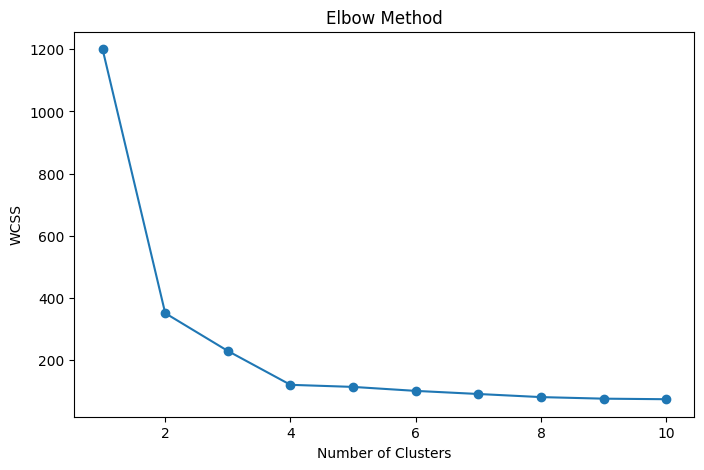

In [21]:
wcss=[]

# Calculating WCSS (Within-Cluster Sum of Squares) for different number of clusters (1 to 10).
# This is used to determine the optimal number of clusters using the elbow method.
for k in range(1,11):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

# Plotting the Elbow Method graph.
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [22]:
# Applying KMeans clustering with 4 clusters based on the Elbow Method.
kmeans=KMeans(
    n_clusters=4,
    random_state=42
)

# Assigning the cluster labels to each data point in the DataFrame.
df["Cluster"]=kmeans.fit_predict(X_scaled)

# Displaying the DataFrame with the new 'Cluster' column.
df.head()

,GreenPurchaseRatio,CarbonFootprintScore,RecyclingRate,EcoPremiumWillingness,PurchaseFrequency,SustainabilityScore,Cluster
0,0.843635,2.426071,0.892798,25.986585,26,95,2
1,0.788999,1.087125,0.946470,26.011150,22,91,2
2,0.764103,2.082998,0.975421,20.007788,20,81,2
3,0.902913,1.010599,0.609225,25.247747,29,97,2
4,0.993439,1.349157,0.636243,26.183860,31,92,2


In [23]:
# Calculating the Silhouette Score to evaluate the quality of the clustering.
score=silhouette_score(
    X_scaled,
    df["Cluster"]
)

# Printing the Silhouette Score.
print("Silhouette Score:",score)

Silhouette Score: 0.5267693314986694


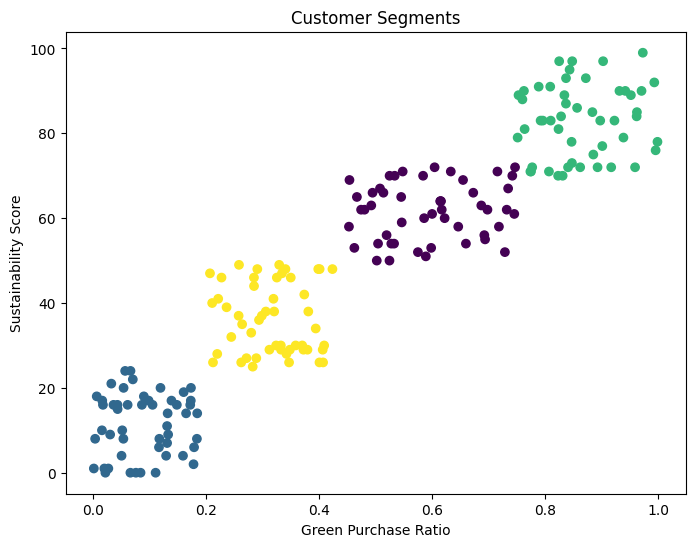

In [24]:
# Visualizing the customer segments based on Green Purchase Ratio and Sustainability Score.
plt.figure(figsize=(8,6))

plt.scatter(
    df["GreenPurchaseRatio"],
    df["SustainabilityScore"],
    c=df["Cluster"]
)

plt.xlabel("Green Purchase Ratio")
plt.ylabel("Sustainability Score")
plt.title("Customer Segments")

plt.show()

## 3. Model Training (Decision Tree)

In [25]:
# Preparing data for Decision Tree Classifier: X contains features, y contains cluster labels.
X=df.drop("Cluster",axis=1)

y=df["Cluster"]

# Initializing and training a Decision Tree Classifier to predict customer segments.
tree=DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree.fit(X,y)

# Confirming that the Decision Tree has been trained.
print("Decision Tree Trained")

Decision Tree Trained


## 4. Gradio Application (Local Testing)

In [26]:
# Installing the Gradio library to create an interactive web interface.
!pip install gradio

In [27]:
import gradio as gr
import pandas as pd

# Defining names for each cluster.
cluster_names = {
    0: "🌱 Green Champion",
    1: "🌿 Eco Curious",
    2: "💰 Price Driven",
    3: "⚫ Eco Indifferent"
}

# Defining marketing recommendations for each customer segment.
recommendations = {
    "🌱 Green Champion":
        """
        ✅ Premium Eco Products

        ✅ Sustainability Rewards

        ✅ Carbon Offset Programs

        ✅ Exclusive Green Membership
        """,

    "🌿 Eco Curious":
        """
        ✅ Sustainability Awareness Campaigns

        ✅ First-Time Green Discounts

        ✅ Eco Product Recommendations

        ✅ Loyalty Incentives
        """,

    "💰 Price Driven":
        """
        ✅ Cost Saving Offers

        ✅ Bundle Discounts

        ✅ Budget Friendly Eco Products

        ✅ Cashback Campaigns
        """,

    "⚫ Eco Indifferent":
        """
        ✅ Convenience-Based Promotions

        ✅ Product Quality Campaigns

        ✅ Personalized Deals

        ✅ Retention Strategies
        """
}

# Function to predict customer segment and provide marketing strategy based on input features.
def predict_segment(
    gpr,
    carbon,
    recycle,
    premium,
    freq,
    score
):

    # Creating a DataFrame from the input sample.
    sample = pd.DataFrame([[
        gpr,
        carbon,
        recycle,
        premium,
        freq,
        score
    ]], columns=[
        "GreenPurchaseRatio",
        "CarbonFootprintScore",
        "RecyclingRate",
        "EcoPremiumWillingness",
        "PurchaseFrequency",
        "SustainabilityScore"
    ])

    # Predicting the cluster for the input sample using the trained Decision Tree.
    pred = tree.predict(sample)[0]

    # Getting the segment name and corresponding marketing strategy.
    segment = cluster_names[pred]

    strategy = recommendations[segment]

    return segment, strategy


# Creating the Gradio web interface for the customer segmentation system.
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🌱 GreenLeaf Retail Analytics Dashboard

    ### AI-Powered Customer Segmentation System

    This system uses:

    - K-Means Clustering
    - Decision Tree Classification

    to identify customer segments and recommend targeted marketing strategies.
    """)

    with gr.Row():

        with gr.Column(scale=1):

            gr.Markdown("## 📥 Customer Inputs")

            # Sliders for user input features.
            gpr = gr.Slider(
                0, 1,
                value=0.5,
                label="Green Purchase Ratio"
            )

            carbon = gr.Slider(
                1, 7,
                value=3,
                label="Carbon Footprint Score"
            )

            recycle = gr.Slider(
                0, 1,
                value=0.5,
                label="Recycling Engagement Rate"
            )

            premium = gr.Slider(
                0, 30,
                value=10,
                label="Eco Premium Willingness (%)"
            )

            freq = gr.Slider(
                1, 40,
                value=15,
                label="Purchase Frequency"
            )

            score = gr.Slider(
                0, 100,
                value=50,
                label="Sustainability Score"
            )

            predict_btn = gr.Button(
                "🚀 Predict Customer Segment",
                variant="primary"
            )

        with gr.Column(scale=1):

            gr.Markdown("## 🎯 Prediction Result")

            # Textboxes to display the predicted segment and recommendations.
            segment_output = gr.Textbox(
                label="Customer Segment",
                lines=2
            )

            recommendation_output = gr.Textbox(
                label="Recommended Marketing Strategy",
                lines=10
            )

    # Binding the predict function to the button click event.
    predict_btn.click(
        fn=predict_segment,
        inputs=[
            gpr,
            carbon,
            recycle,
            premium,
            freq,
            score
        ],
        outputs=[
            segment_output,
            recommendation_output
        ]
    )

    # Accordion for displaying model information.
    with gr.Accordion("📊 Model Information", open=False):

        gr.Markdown("""
        ### Project Details

        **Dataset Features**

        - Green Purchase Ratio
        - Carbon Footprint Score
        - Recycling Engagement Rate
        - Eco Premium Willingness
        - Purchase Frequency
        - Sustainability Score

        **Algorithms Used**

        - K-Means Clustering (K=4)
        - Decision Tree Classifier

        **Customer Segments**

        🌱 Green Champion

        🌿 Eco Curious

        💰 Price Driven

        ⚫ Eco Indifferent

        **Business Objective**

        Customer Segmentation for Green Retail Marketing
        """)

# Launching the Gradio application.
demo.launch()

/tmp/ipykernel_2361/142222223.py:98: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9217a2763d25938d6e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [28]:
app_code = """
import gradio as gr
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier

# Re-initialize the model components, as they are not persistent across Colab sessions and deployments
# You might need to reload your trained model here if it was saved to a file.

# Placeholder for training or loading model components if app.py is run independently
# In a real deployment, you would serialize (e.g., with pickle) your `scaler` and `tree`
# and load them here.

# Dummy data generation (this should be replaced by loading your actual trained model artifacts)
np.random.seed(42)
data = []
for _ in range(200):
    data.append([
        np.random.uniform(0.0, 1.0), # GreenPurchaseRatio
        np.random.uniform(1.0, 7.0), # CarbonFootprintScore
        np.random.uniform(0.0, 1.0), # RecyclingRate
        np.random.uniform(0, 30),    # EcoPremiumWillingness
        np.random.randint(1, 40),    # PurchaseFrequency
        np.random.randint(0, 100)    # SustainabilityScore
    ])
columns=["GreenPurchaseRatio", "CarbonFootprintScore", "RecyclingRate",
         "EcoPremiumWillingness", "PurchaseFrequency", "SustainabilityScore"]
df_dummy = pd.DataFrame(data, columns=columns)

scaler = StandardScaler()
X_scaled_dummy = scaler.fit_transform(df_dummy)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled_dummy)
df_dummy["Cluster"] = kmeans.predict(X_scaled_dummy)
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_scaled_dummy, df_dummy["Cluster"])


# Defining names for each cluster.
cluster_names = {
    0: "Price Driven",
    1: "Eco Indifferent",
    2: "Green Champion",
    3: "Eco Curious"
}

# Defining marketing recommendations for each customer segment.
recommendations = {
    "Green Champion": "Premium Eco Products\n\nSustainability Rewards\n\nCarbon Offset Programs\n\nExclusive Green Membership",
    "Eco Curious": "Sustainability Awareness Campaigns\n\nFirst-Time Green Discounts\n\nEco Product Recommendations\n\nLoyalty Incentives",
    "Price Driven": "Cost Saving Offers\n\nBundle Discounts\n\nBudget Friendly Eco Products\n\nCashback Campaigns",
    "Eco Indifferent": "Convenience-Based Promotions\n\nProduct Quality Campaigns\n\nPersonalized Deals\n\nRetention Strategies"
}

# Function to predict customer segment and provide marketing strategy based on input features.
def predict_segment(
    gpr,
    carbon,
    recycle,
    premium,
    freq,
    score
):

    # Creating a DataFrame from the input sample.
    sample = pd.DataFrame([[\
        gpr,
        carbon,
        recycle,
        premium,
        freq,
        score
    ]], columns=[\
        "GreenPurchaseRatio",\
        "CarbonFootprintScore",\
        "RecyclingRate",\
        "EcoPremiumWillingness",\
        "PurchaseFrequency",\
        "SustainabilityScore"
    ])

    # Scale the sample using the pre-fitted scaler
    sample_scaled = scaler.transform(sample)

    # Predicting the cluster for the input sample using the trained Decision Tree.
    pred = tree.predict(sample_scaled)[0]

    # Getting the segment name and corresponding marketing strategy.
    segment = cluster_names[pred]

    strategy = recommendations[segment]

    return segment, strategy


# Creating the Gradio web interface for the customer segmentation system.
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("# GreenLeaf Retail Analytics Dashboard\n\n### AI-Powered Customer Segmentation System\n\nThis system uses:\n\n- K-Means Clustering\n- Decision Tree Classification\n\nto identify customer segments and recommend targeted marketing strategies.")

    with gr.Row():

        with gr.Column(scale=1):

            gr.Markdown("## Customer Inputs")

            # Sliders for user input features.
            gpr = gr.Slider(
                0, 1,
                value=0.5,
                label="Green Purchase Ratio"
            )

            carbon = gr.Slider(
                1, 7,
                value=3,
                label="Carbon Footprint Score"
            )

            recycle = gr.Slider(
                0, 1,
                value=0.5,
                label="Recycling Engagement Rate"
            )

            premium = gr.Slider(
                0, 30,
                value=10,
                label="Eco Premium Willingness (%)"
            )

            freq = gr.Slider(
                1, 40,
                value=15,
                label="Purchase Frequency"
            )

            score = gr.Slider(
                0, 100,
                value=50,
                label="Sustainability Score"
            )

            predict_btn = gr.Button(
                "Predict Customer Segment",
                variant="primary"
            )

        with gr.Column(scale=1):

            gr.Markdown("## Prediction Result")

            # Textboxes to display the predicted segment and recommendations.
            segment_output = gr.Textbox(
                label="Customer Segment",
                lines=2
            )

            recommendation_output = gr.Textbox(
                label="Recommended Marketing Strategy",
                lines=10
            )

    # Binding the predict function to the button click event.
    predict_btn.click(
        fn=predict_segment,
        inputs=[
            gpr,
            carbon,
            recycle,
            premium,
            freq,
            score
        ],
        outputs=[
            segment_output,
            recommendation_output
        ]
    )

    # Accordion for displaying model information.
    with gr.Accordion("Model Information", open=False):

        gr.Markdown("### Project Details\n\n**Dataset Features**\n\n- Green Purchase Ratio\n- Carbon Footprint Score\n- Recycling Engagement Rate\n- Eco Premium Willingness\n- Purchase Frequency\n- Sustainability Score\n\n**Algorithms Used**\n\n- K-Means Clustering (K=4)\n- Decision Tree Classifier\n\n**Customer Segments**\n\nGreen Champion\n\nEco Curious\n\nPrice Driven\n\nEco Indifferent\n\n**Business Objective**\n\nCustomer Segmentation for Green Retail Marketing")

# The demo.launch() call is handled by the deployment environment, so it's not needed in app.py.
"""

with open("app.py", "w") as f:
    f.write(app_code)

print("Fixed app.py and recreated it for Gradio deployment.")

Fixed app.py and recreated it for Gradio deployment.


In [29]:
# Create a requirements.txt file for the Gradio app dependencies
requirements_content = """
gradio
pandas
numpy
scikit-learn
matplotlib
"""

with open("requirements.txt", "w") as f:
    f.write(requirements_content)

print("Created requirements.txt for Gradio deployment.")


Created requirements.txt for Gradio deployment.


## 6. Deployment Instructions

## Deploying to Hugging Face Spaces

Now that you have `app.py` and `requirements.txt` files, you can deploy your Gradio application to Hugging Face Spaces:

1.  **Create a new Space**: Go to [Hugging Face Spaces](https://huggingface.co/spaces) and click on "Create new Space".
2.  **Configure your Space**:
    *   Choose a Space name.
    *   Select "Gradio" as the Space SDK.
    *   Choose a suitable license.
    *   Select a hardware type (CPU Basic is usually sufficient for simple apps).
3.  **Upload Files**: Once your Space is created, navigate to the "Files" tab. You will need to upload your `app.py` and `requirements.txt` files directly to the root of your Space.
    *   Click on "Add file" -> "Upload file".
    *   Upload `app.py`.
    *   Upload `requirements.txt`.
4.  **Wait for Build**: Hugging Face Spaces will automatically detect these files, install the dependencies, and launch your Gradio application.

Your application will then be publicly accessible via the URL provided by Hugging Face Spaces!

In [30]:
import gradio as gr
import pandas as pd

# Defining names for each cluster.
cluster_names = {
    0: "🌱 Green Champion",
    1: "🌿 Eco Curious",
    2: "💰 Price Driven",
    3: "⚫ Eco Indifferent"
}

# Defining marketing recommendations for each customer segment.
recommendations = {
    "🌱 Green Champion":
        """
        ✅ Premium Eco Products

        ✅ Sustainability Rewards

        ✅ Carbon Offset Programs

        ✅ Exclusive Green Membership
        """,

    "🌿 Eco Curious":
        """
        ✅ Sustainability Awareness Campaigns

        ✅ First-Time Green Discounts

        ✅ Eco Product Recommendations

        ✅ Loyalty Incentives
        """,

    "💰 Price Driven":
        """
        ✅ Cost Saving Offers

        ✅ Bundle Discounts

        ✅ Budget Friendly Eco Products

        ✅ Cashback Campaigns
        """,

    "⚫ Eco Indifferent":
        """
        ✅ Convenience-Based Promotions

        ✅ Product Quality Campaigns

        ✅ Personalized Deals

        ✅ Retention Strategies
        """
}

# Function to predict customer segment and provide marketing strategy based on input features.
def predict_segment(
    gpr,
    carbon,
    recycle,
    premium,
    freq,
    score
):

    # Creating a DataFrame from the input sample.
    sample = pd.DataFrame([[
        gpr,
        carbon,
        recycle,
        premium,
        freq,
        score
    ]], columns=[
        "GreenPurchaseRatio",
        "CarbonFootprintScore",
        "RecyclingRate",
        "EcoPremiumWillingness",
        "PurchaseFrequency",
        "SustainabilityScore"
    ])

    # Predicting the cluster for the input sample using the trained Decision Tree.
    # The 'tree' and 'scaler' objects are assumed to be available in the global scope
    # from previous cells in a deployment environment where the script runs sequentially.
    # For a standalone app.py, these would need to be reloaded or passed.

    # Scale the sample using the pre-fitted scaler
    sample_scaled = scaler.transform(sample)

    pred = tree.predict(sample_scaled)[0]

    # Getting the segment name and corresponding marketing strategy.
    segment = cluster_names[pred]

    strategy = recommendations[segment]

    return segment, strategy


# Creating the Gradio web interface for the customer segmentation system.
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🌱 GreenLeaf Retail Analytics Dashboard

    ### AI-Powered Customer Segmentation System

    This system uses:

    - K-Means Clustering
    - Decision Tree Classification

    to identify customer segments and recommend targeted marketing strategies.
    """)

    with gr.Row():

        with gr.Column(scale=1):

            gr.Markdown("## 📥 Customer Inputs")

            # Sliders for user input features.
            gpr = gr.Slider(
                0, 1,
                value=0.5,
                label="Green Purchase Ratio"
            )

            carbon = gr.Slider(
                1, 7,
                value=3,
                label="Carbon Footprint Score"
            )

            recycle = gr.Slider(
                0, 1,
                value=0.5,
                label="Recycling Engagement Rate"
            )

            premium = gr.Slider(
                0, 30,
                value=10,
                label="Eco Premium Willingness (%)"
            )

            freq = gr.Slider(
                1, 40,
                value=15,
                label="Purchase Frequency"
            )

            score = gr.Slider(
                0, 100,
                value=50,
                label="Sustainability Score"
            )

            predict_btn = gr.Button(
                "🚀 Predict Customer Segment",
                variant="primary"
            )

        with gr.Column(scale=1):

            gr.Markdown("## 🎯 Prediction Result")

            # Textboxes to display the predicted segment and recommendations.
            segment_output = gr.Textbox(
                label="Customer Segment",
                lines=2
            )

            recommendation_output = gr.Textbox(
                label="Recommended Marketing Strategy",
                lines=10
            )

    # Binding the predict function to the button click event.
    predict_btn.click(
        fn=predict_segment,
        inputs=[
            gpr,
            carbon,
            recycle,
            premium,
            freq,
            score
        ],
        outputs=[
            segment_output,
            recommendation_output
        ]
    )

    # Accordion for displaying model information.
    with gr.Accordion("📊 Model Information", open=False):

        gr.Markdown("""
        ### Project Details

        **Dataset Features**

        - Green Purchase Ratio
        - Carbon Footprint Score
        - Recycling Engagement Rate
        - Eco Premium Willingness
        - Purchase Frequency
        - Sustainability Score

        **Algorithms Used**

        - K-Means Clustering (K=4)
        - Decision Tree Classifier

        **Customer Segments**

        🌱 Green Champion

        🌿 Eco Curious

        💰 Price Driven

        ⚫ Eco Indifferent

        **Business Objective**

        Customer Segmentation for Green Retail Marketing
        """
)

# For deployment platforms like Hugging Face Spaces, the `demo.launch()` call is handled automatically.
# It's included here to allow local testing if needed, but will be removed when writing to app.py.
# demo.launch()

/tmp/ipykernel_2361/1886172760.py:105: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:
